In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
length=8

In [3]:
nb=16
ID_list_4=[]
nn=6
for i in range(nn):
    npzfile = np.load('run_nk4_ndiag'+str(nb*(i))+'.npz')
    # print(npzfile.files)
    ID_list_4.append(npzfile['ID_list'])
    nen_list=npzfile['nen_list']
    nsub_list=npzfile['nsub_list']

In [4]:
ID_list_4[5][0,0,0]

6.59800025048289e-06

In [5]:
nb=16
ID_list_6=[]
nn=5
for i in range(nn):
    npzfile = np.load('run_nk6_ndiag'+str(nb*(i))+'.npz')
    # print(npzfile.files)
    ID_list_6.append(npzfile['ID_list'])
    nen_list=npzfile['nen_list']
    nsub_list=npzfile['nsub_list']

In [6]:
nb=16
ID_list_8=[]
nn=3
for i in range(nn):
    npzfile = np.load('run_nk8_ndiag'+str(nb*(i))+'.npz')
    # print(npzfile.files)
    ID_list_8.append(npzfile['ID_list'])
    nen_list=npzfile['nen_list']
    nsub_list=npzfile['nsub_list']

(0.0, 1.5435597245574188e-05)

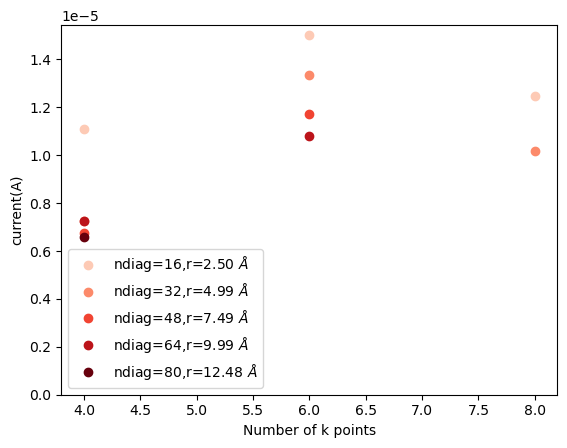

In [7]:
from matplotlib import cm
brewer_cmap = cm.get_cmap('Reds')
colors = brewer_cmap(np.linspace(0,1,len(ID_list_4)))
Lx=2.496266
for i in range(1,len(ID_list_4)):
    plt.plot(4,ID_list_4[i][0,0,0],'o',c=colors[i],label='ndiag='+str(nb*(i))+',r='+'{:.2f}'.format(Lx*(i))+r" $\AA$")
for i in range(1,len(ID_list_6)):    
    plt.plot(6,ID_list_6[i][0,0,0],'o',c=colors[i])
for i in range(1,len(ID_list_8)):    
    plt.plot(8,ID_list_8[i][0,0,0],'o',c=colors[i])    
plt.xlabel('Number of k points')
plt.ylabel('current(A)')
plt.legend()
plt.ylim(0,)

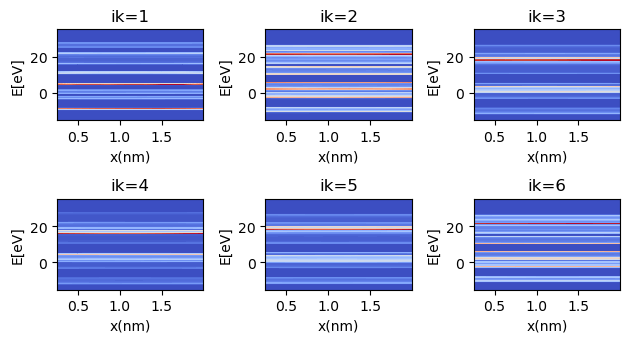

In [15]:
nx=length
Lx=2.496266
emin=-15.0
emax=35.0
nk=6
for i in range(nk):
    plt.subplot(3,3,i+1)
    plt.title('ik='+str(i+1))
    ldos=np.loadtxt('last_ldos000'+str(i+1)+'.dat')
    nen=ldos.shape[0]//nx
    en=np.linspace(emin,emax,nen)
    x=np.linspace(1,nx,nx)*Lx
    ldos=np.reshape(ldos[:,3],(nen,nx))
    if(i==0):
        sum_ldos=ldos/nk
    else:
        sum_ldos=ldos/nk+sum_ldos
    plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
    plt.xlabel('x(nm)')
    plt.ylabel('E[eV]')
    plt.tight_layout()
plt.show()    

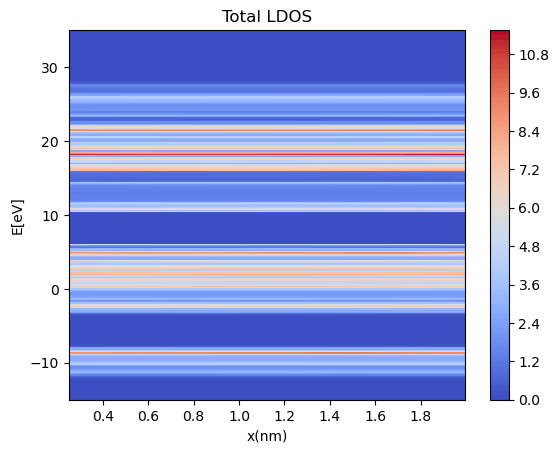

In [21]:
# nx=12
# Lx=3.1680940
# emin=-10.0
# emax=4.0
# x=np.linspace(1,nx,nx)*Lx
plt.title('Total LDOS')
# ldos=np.loadtxt('gw_ldos0010.dat')
# nen=ldos.shape[0]//nx
# en=np.linspace(emin,emax,nen)
# ldos=np.reshape(ldos[:,3],(nen,nx))
plt.contourf(x/10,en,sum_ldos,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')
# plt.ylim(2,8)
plt.colorbar()

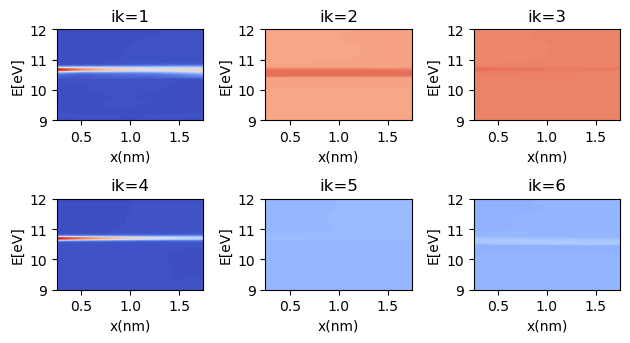

In [10]:
nx=length-1
for i in range(nk):
    plt.subplot(3,3,i+1)
    plt.title('ik='+str(i+1))
    ldos=np.loadtxt('last_Jdens000'+str(i+1)+'.dat')
    nen=ldos.shape[0]//nx
    en=np.linspace(emin,emax,nen)
    x=np.linspace(1,nx,nx)*Lx
    ldos=np.reshape(ldos[:,2],(nen,nx))
    if(i==0):
        sum_ldos=ldos/nk
    else:
        sum_ldos=ldos/nk+sum_ldos
    plt.contourf(x/10,en,ldos,100, cmap='coolwarm')
    plt.xlabel('x(nm)')
    plt.ylabel('E[eV]')
    plt.ylim(9,12)
    # plt.colorbar()
    plt.tight_layout()


(9.0, 12.0)

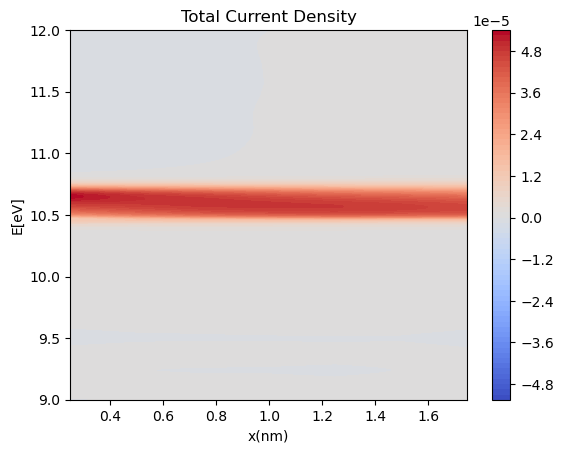

In [11]:
# nx=11
# Lx=3.1680940
# emin=-10.0
# emax=4.0
plt.title('Total Current Density')
# ldos=np.loadtxt('gw_Jdens0010.dat')
# nen=ldos.shape[0]//nx
# en=np.linspace(emin,emax,nen)
# x=np.linspace(1,nx,nx)*Lx
# ldos=np.reshape(ldos[:,2],(nen,nx))
plt.contourf(x/10,en,sum_ldos,100, cmap='coolwarm')
plt.xlabel('x(nm)')
plt.ylabel('E[eV]')
plt.colorbar()
plt.ylim(9,12)

In [12]:
ids=np.loadtxt('gw_Id_iteration.dat')
error=np.loadtxt('gw_scba_error.dat')
it=ids[:,0]
nn=[0]
for j in range(1,len(it)):
    if(it[j]<it[j-1]):
        nn.append(j)
it2=error[:,0]
nn2=[0]
for j in range(1,len(it2)):
    if(it2[j]<it2[j-1]):
        nn2.append(j)        

In [ ]:
from matplotlib import cm
brewer_cmap = cm.get_cmap('Reds')
colors = brewer_cmap(np.linspace(0,1,len(nn)))

plt.subplot(1,3,1)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],1],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('current(A)')
plt.title('left contact')
plt.subplot(1,3,2)
for i in range(len(nn)-1):    
    plt.plot(it[nn[i]:nn[i+1]], ids[nn[i]:nn[i+1],2],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('')
plt.title('right contact')
plt.subplot(1,3,3)
for i in range(len(nn2)-1):    
    plt.plot(it2[nn2[i]:nn2[i+1]], error[nn2[i]:nn2[i+1],1],c=colors[i])    
plt.xlabel('iteration')
plt.ylabel('')
plt.title('SCBA error \n $||\Sigma^r_{new}-\Sigma^r_{old}||/||\Sigma^r_{old}||$')
plt.yscale('log')
plt.tight_layout()

In [14]:
len(nn)

15